# MOUNT DRIVE DAN IMPORT LIBRARY


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import xgboost as xgb
import joblib

print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

Mounted at /content/drive
TF version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# SETTING PATH DAN PARAMETER

In [ ]:
# Buat folder checkpoint
os.makedirs('/content/drive/Shareddrives/ML/checkpoints', exist_ok=True)

# Copy dataset dari Drive ke lokal Colab
# Sesuaikan path ini jika folder dataset kamu beda
!cp -r '/content/drive/Shareddrives/ML/PlantVillage' '/content/PlantVillage'

DATASET_PATH = '/content/PlantVillage'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_CNN = 20
EPOCHS_EFF = 10
SEED = 42

class_names = sorted([
    folder for folder in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, folder))
])

NUM_CLASSES = len(class_names)

print("Jumlah kelas:", NUM_CLASSES)
print("Daftar kelas:")
for i, cls in enumerate(class_names):
    print(i, cls)

Jumlah kelas: 15
Daftar kelas:
0 Pepper__bell___Bacterial_spot
1 Pepper__bell___healthy
2 Potato___Early_blight
3 Potato___Late_blight
4 Potato___healthy
5 Tomato_Bacterial_spot
6 Tomato_Early_blight
7 Tomato_Late_blight
8 Tomato_Leaf_Mold
9 Tomato_Septoria_leaf_spot
10 Tomato_Spider_mites_Two_spotted_spider_mite
11 Tomato__Target_Spot
12 Tomato__Tomato_YellowLeaf__Curl_Virus
13 Tomato__Tomato_mosaic_virus
14 Tomato_healthy


# CALLBACKS

In [ ]:
def get_callbacks(model_name):
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=3,
            verbose=1
        ),
        ModelCheckpoint(
            f'/content/drive/Shareddrives/ML/checkpoints/{model_name}_best.keras',
            save_best_only=True,
            monitor='val_loss',
            verbose=1
        )
    ]

# EKSPLORASI DATASET

Total gambar: 20638

Distribusi kelas:
                                      Class  Count
      Tomato__Tomato_YellowLeaf__Curl_Virus   3208
                      Tomato_Bacterial_spot   2127
                         Tomato_Late_blight   1909
                  Tomato_Septoria_leaf_spot   1771
Tomato_Spider_mites_Two_spotted_spider_mite   1676
                             Tomato_healthy   1591
                     Pepper__bell___healthy   1478
                        Tomato__Target_Spot   1404
                      Potato___Early_blight   1000
                       Potato___Late_blight   1000
                        Tomato_Early_blight   1000
              Pepper__bell___Bacterial_spot    997
                           Tomato_Leaf_Mold    952
                Tomato__Tomato_mosaic_virus    373
                           Potato___healthy    152


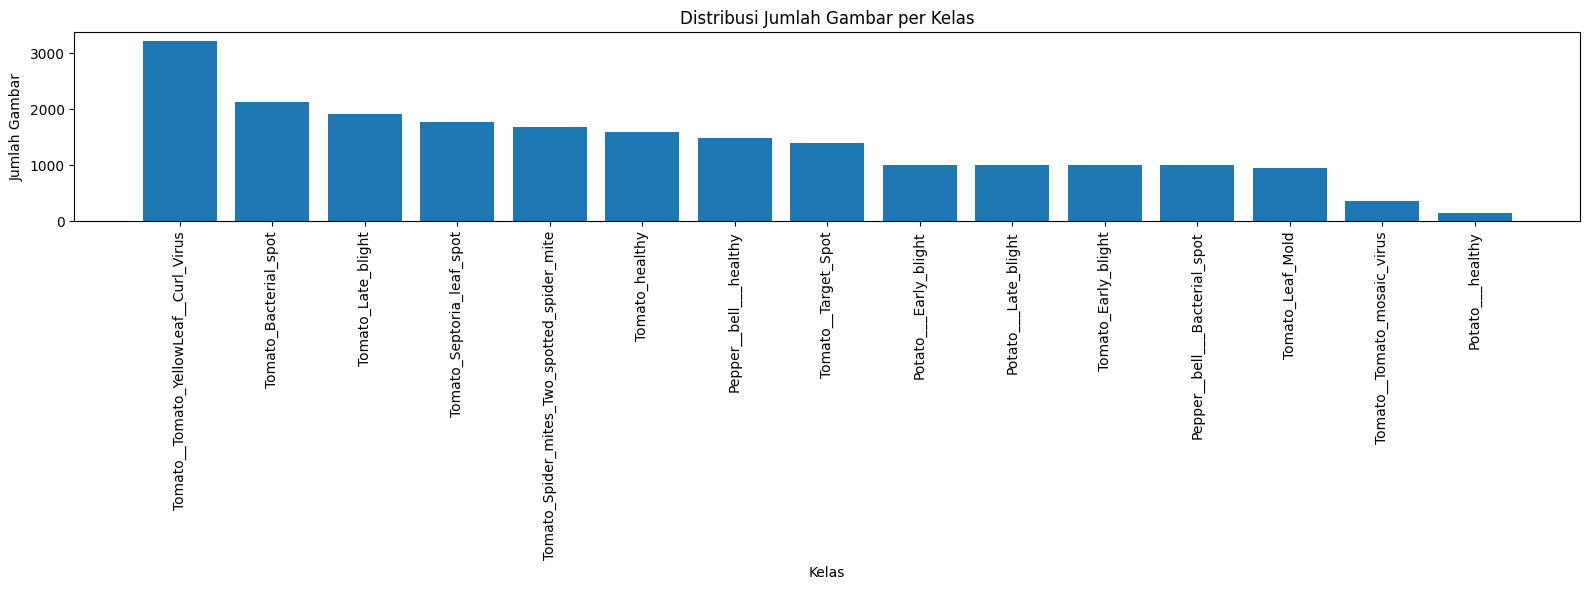

In [ ]:
class_counts = {}

for cls in class_names:
    cls_path = os.path.join(DATASET_PATH, cls)
    if os.path.isdir(cls_path):
        class_counts[cls] = len([
            file for file in os.listdir(cls_path)
            if file.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])

df_counts = pd.DataFrame(
    list(class_counts.items()),
    columns=['Class', 'Count']
).sort_values('Count', ascending=False)

print("Total gambar:", df_counts['Count'].sum())
print("\nDistribusi kelas:")
print(df_counts.to_string(index=False))

plt.figure(figsize=(16, 6))
plt.bar(df_counts['Class'], df_counts['Count'])
plt.xticks(rotation=90)
plt.title('Distribusi Jumlah Gambar per Kelas')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Gambar')
plt.tight_layout()
plt.show()

# GENERATOR UNTUK CNN SEDERHANA

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

val_gen = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

print("Train CNN:", train_gen.samples)
print("Val CNN  :", val_gen.samples)

Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.
Train CNN: 16516
Val CNN  : 4122


# GENERATOR UNTUK EFFICIENTNETB0

In [ ]:
eff_train_datagen = ImageDataGenerator(
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

eff_val_datagen = ImageDataGenerator(
    validation_split=0.2
)

eff_train_gen = eff_train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

eff_val_gen = eff_val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

print("Train EfficientNet:", eff_train_gen.samples)
print("Val EfficientNet  :", eff_val_gen.samples)

Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.
Train EfficientNet: 16516
Val EfficientNet  : 4122


# CLASS WEIGHT UNTUK MENGATASI IMBALANCE

In [ ]:
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)

class_weights = dict(enumerate(class_weights_array))

print("Class Weight:")
for idx, weight in class_weights.items():
    print(f"{idx} - {class_names[idx]} : {weight:.4f}")

Class Weight:
0 - Pepper__bell___Bacterial_spot : 1.3798
1 - Pepper__bell___healthy : 0.9307
2 - Potato___Early_blight : 1.3763
3 - Potato___Late_blight : 1.3763
4 - Potato___healthy : 9.0251
5 - Tomato_Bacterial_spot : 0.6469
6 - Tomato_Early_blight : 1.3763
7 - Tomato_Late_blight : 0.7206
8 - Tomato_Leaf_Mold : 1.4450
9 - Tomato_Septoria_leaf_spot : 0.7770
10 - Tomato_Spider_mites_Two_spotted_spider_mite : 0.8211
11 - Tomato__Target_Spot : 0.9796
12 - Tomato__Tomato_YellowLeaf__Curl_Virus : 0.4289
13 - Tomato__Tomato_mosaic_virus : 3.6825
14 - Tomato_healthy : 0.8649


# MODEL 1: CNN SEDERHANA

In [ ]:
# 8. MODEL 1: CNN SEDERHANA

def build_cnn(num_classes, input_shape=(224, 224, 3)):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

cnn_model = build_cnn(NUM_CLASSES)

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,248,527 (84.87 MB)

 Trainable params: 22,248,527 (84.87 MB)

 Non-trainable params: 0 (0.00 B)

# TRAINING CNN DENGAN CLASS WEIGHT

In [ ]:
history_cnn = cnn_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_CNN,
    callbacks=get_callbacks('cnn_balanced'),
    class_weight=class_weights
)

# cnn_model.save('/content/drive/Shareddrives/ML/checkpoints/cnn_balanced_final.keras')

Epoch 1/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.2870 - loss: 2.2910
Epoch 1: val_loss improved from None to 0.86142, saving model to /content/drive/Shareddrives/ML/checkpoints/cnn_balanced_best.keras

Epoch 1: finished saving model to /content/drive/Shareddrives/ML/checkpoints/cnn_balanced_best.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 259s 482ms/step - accuracy: 0.4333 - loss: 1.7966 - val_accuracy: 0.7176 - val_loss: 0.8614 - learning_rate: 0.0010
Epoch 2/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.6643 - loss: 1.0281
Epoch 2: val_loss did not improve from 0.86142
517/517 ━━━━━━━━━━━━━━━━━━━━ 236s 457ms/step - accuracy: 0.6808 - loss: 0.9828 - val_accuracy: 0.7077 - val_loss: 0.9039 - learning_rate: 0.0010
Epoch 3/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.7346 - loss: 0.7881
Epoch 3: val_loss improved from 0.86142 to 0.84411, saving model to /content/drive/Shareddrives/ML/checkpoints/cnn_balanced_best.keras

Epoch 3: finished saving mode

# PLOT TRAINING CNN

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Val Accuracy')
plt.title('CNN Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Val Loss')
plt.title('CNN Loss')
plt.legend()

plt.tight_layout()
plt.show()

# MODEL 2: EFFICIENTNETB0 TRANSFER LEARNING

In [ ]:
def build_efficientnet(num_classes, input_shape=(224, 224, 3)):
    inputs = layers.Input(shape=input_shape)

    # Preprocessing khusus EfficientNet
    x = layers.Lambda(preprocess_input)(inputs)

    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_tensor=x
    )

    base_model.trainable = False

    x = layers.GlobalAveragePooling2D(name='feature_vector')(base_model.output)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)

    return model, base_model

effnet_model, effnet_base = build_efficientnet(NUM_CLASSES)

effnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

effnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ lambda[0][0]      │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati

 Total params: 4,381,362 (16.71 MB)

 Trainable params: 331,791 (1.27 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

# TRAINING EFFICIENTNET PHASE 1

In [ ]:
history_eff1 = effnet_model.fit(
    eff_train_gen,
    validation_data=eff_val_gen,
    epochs=EPOCHS_EFF,
    callbacks=get_callbacks('effnet_phase1_balanced'),
    class_weight=class_weights
)

# effnet_model.save('/content/drive/Shareddrives/ML/checkpoints/effnet_phase1_balanced_final.keras')

Epoch 1/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.6168 - loss: 1.2242
Epoch 1: val_loss improved from None to 0.38483, saving model to /content/drive/Shareddrives/ML/checkpoints/effnet_phase1_balanced_best.keras

Epoch 1: finished saving model to /content/drive/Shareddrives/ML/checkpoints/effnet_phase1_balanced_best.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 298s 516ms/step - accuracy: 0.7373 - loss: 0.8172 - val_accuracy: 0.8787 - val_loss: 0.3848 - learning_rate: 0.0010
Epoch 2/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.8377 - loss: 0.4598
Epoch 2: val_loss improved from 0.38483 to 0.27276, saving model to /content/drive/Shareddrives/ML/checkpoints/effnet_phase1_balanced_best.keras

Epoch 2: finished saving model to /content/drive/Shareddrives/ML/checkpoints/effnet_phase1_balanced_best.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 216s 418ms/step - accuracy: 0.8456 - loss: 0.4413 - val_accuracy: 0.9127 - val_loss: 0.2728 - learning_rate: 0.0010
Epoch 3/10
517/517 ━━━━

# TRAINING EFFICIENTNET PHASE 2 / FINE-TUNING


In [ ]:
effnet_base.trainable = True

for layer in effnet_base.layers[:-30]:
    layer.trainable = False

effnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_eff2 = effnet_model.fit(
    eff_train_gen,
    validation_data=eff_val_gen,
    epochs=10,
    callbacks=get_callbacks('effnet_phase2_balanced'),
    class_weight=class_weights
)

# effnet_model.save('/content/drive/Shareddrives/ML/checkpoints/effnet_phase2_balanced_final.keras')

Epoch 1/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.7403 - loss: 0.8812
Epoch 1: val_loss improved from None to 0.31639, saving model to /content/drive/Shareddrives/ML/checkpoints/effnet_phase2_balanced_best.keras

Epoch 1: finished saving model to /content/drive/Shareddrives/ML/checkpoints/effnet_phase2_balanced_best.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 284s 487ms/step - accuracy: 0.7820 - loss: 0.6978 - val_accuracy: 0.8869 - val_loss: 0.3164 - learning_rate: 1.0000e-05
Epoch 2/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.8477 - loss: 0.4288
Epoch 2: val_loss improved from 0.31639 to 0.24946, saving model to /content/drive/Shareddrives/ML/checkpoints/effnet_phase2_balanced_best.keras

Epoch 2: finished saving model to /content/drive/Shareddrives/ML/checkpoints/effnet_phase2_balanced_best.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 224s 434ms/step - accuracy: 0.8526 - loss: 0.4155 - val_accuracy: 0.9083 - val_loss: 0.2495 - learning_rate: 1.0000e-05
Epoch 3/10
517/

# PLOT TRAINING EFFICIENTNET

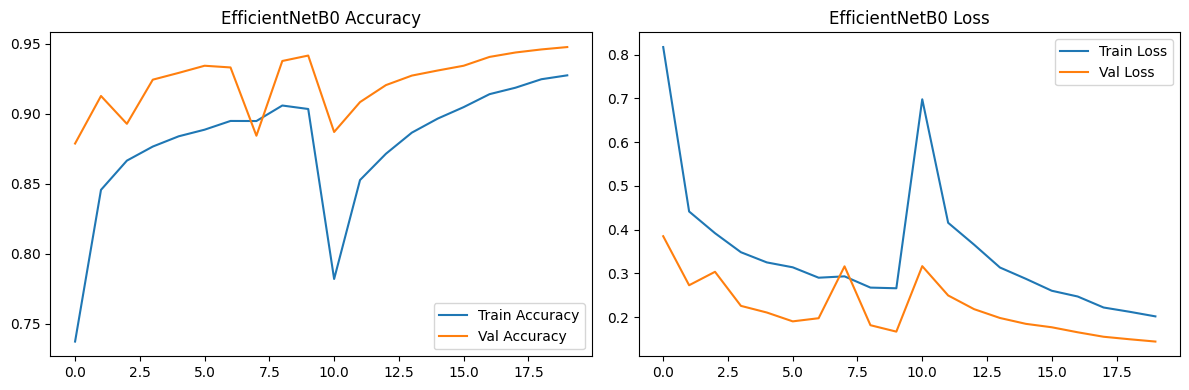

In [ ]:
acc = history_eff1.history['accuracy'] + history_eff2.history['accuracy']
val_acc = history_eff1.history['val_accuracy'] + history_eff2.history['val_accuracy']
loss = history_eff1.history['loss'] + history_eff2.history['loss']
val_loss = history_eff1.history['val_loss'] + history_eff2.history['val_loss']

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.title('EfficientNetB0 Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.title('EfficientNetB0 Loss')
plt.legend()

plt.tight_layout()
plt.show()

# FEATURE EXTRACTION UNTUK HYBRID EFFICIENTNETB0-XGBOOST

In [ ]:
feature_extractor = models.Model(
    inputs=effnet_model.input,
    outputs=effnet_model.get_layer('feature_vector').output
)

extract_datagen = ImageDataGenerator(validation_split=0.2)

train_ext = extract_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=False,
    seed=SEED
)

val_ext = extract_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

print("Mengekstrak fitur train...")
X_train_feat = feature_extractor.predict(train_ext, verbose=1)
y_train_feat = train_ext.classes

print("Mengekstrak fitur validation...")
X_val_feat = feature_extractor.predict(val_ext, verbose=1)
y_val_feat = val_ext.classes

print("Shape X_train_feat:", X_train_feat.shape)
print("Shape X_val_feat  :", X_val_feat.shape)

Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.
Mengekstrak fitur train...
517/517 ━━━━━━━━━━━━━━━━━━━━ 43s 71ms/step
Mengekstrak fitur validation...
129/129 ━━━━━━━━━━━━━━━━━━━━ 12s 90ms/step
Shape X_train_feat: (16516, 1280)
Shape X_val_feat  : (4122, 1280)


# MODEL 3: TRAINING XGBOOST DENGAN SAMPLE WEIGHT

In [ ]:
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train_feat
)

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=SEED,
    n_jobs=-1
)

print("Training XGBoost...")

xgb_model.fit(
    X_train_feat,
    y_train_feat,
    sample_weight=sample_weights,
    eval_set=[(X_val_feat, y_val_feat)],
    verbose=50
)

print("Training XGBoost selesai.")

joblib.dump(
    xgb_model,
    '/content/drive/Shareddrives/ML/checkpoints/xgb_balanced_model.pkl'
)

Training XGBoost...
[0]	validation_0-mlogloss:2.52093
[50]	validation_0-mlogloss:0.63957
[100]	validation_0-mlogloss:0.33342
[150]	validation_0-mlogloss:0.22714
[199]	validation_0-mlogloss:0.17970
Training XGBoost selesai.


['/content/drive/Shareddrives/ML/checkpoints/xgb_balanced_model.pkl']

# FUNGSI EVALUASI MODEL

In [ ]:
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)

    precision_macro = precision_score(
        y_true, y_pred,
        average='macro',
        zero_division=0
    )

    recall_macro = recall_score(
        y_true, y_pred,
        average='macro',
        zero_division=0
    )

    f1_macro = f1_score(
        y_true, y_pred,
        average='macro',
        zero_division=0
    )

    f1_weighted = f1_score(
        y_true, y_pred,
        average='weighted',
        zero_division=0
    )

    print("\n" + "=" * 70)
    print("Model           :", name)
    print(f"Accuracy        : {acc:.4f}")
    print(f"Macro Precision : {precision_macro:.4f}")
    print(f"Macro Recall    : {recall_macro:.4f}")
    print(f"Macro F1-Score  : {f1_macro:.4f}")
    print(f"Weighted F1     : {f1_weighted:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    ))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(14, 12))
    sns.heatmap(
        cm,
        annot=False,
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return {
        'Model': name,
        'Accuracy': acc,
        'Macro Precision': precision_macro,
        'Macro Recall': recall_macro,
        'Macro F1-Score': f1_macro,
        'Weighted F1-Score': f1_weighted
    }

# EVALUASI MODEL 1: CNN SEDERHANA

In [ ]:
results_list = []

val_gen.reset()

y_true_cnn = val_gen.classes
y_pred_cnn = np.argmax(
    cnn_model.predict(val_gen, verbose=1),
    axis=1
)

result_cnn = evaluate_model(
    "CNN Sederhana",
    y_true_cnn,
    y_pred_cnn
)

results_list.append(result_cnn)

# EVALUASI MODEL 2: EFFICIENTNETB0

129/129 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step

Model           : EfficientNetB0
Accuracy        : 0.9476
Macro Precision : 0.9434
Macro Recall    : 0.9537
Macro F1-Score  : 0.9479
Weighted F1     : 0.9481

Classification Report:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.98      0.98      0.98       199
                     Pepper__bell___healthy       0.99      0.99      0.99       295
                      Potato___Early_blight       1.00      1.00      1.00       200
                       Potato___Late_blight       0.97      0.96      0.97       200
                           Potato___healthy       0.91      1.00      0.95        30
                      Tomato_Bacterial_spot       0.98      0.92      0.95       425
                        Tomato_Early_blight       0.92      0.85      0.88       200
                         Tomato_Late_blight       0.97      0.94      0.96       381
         

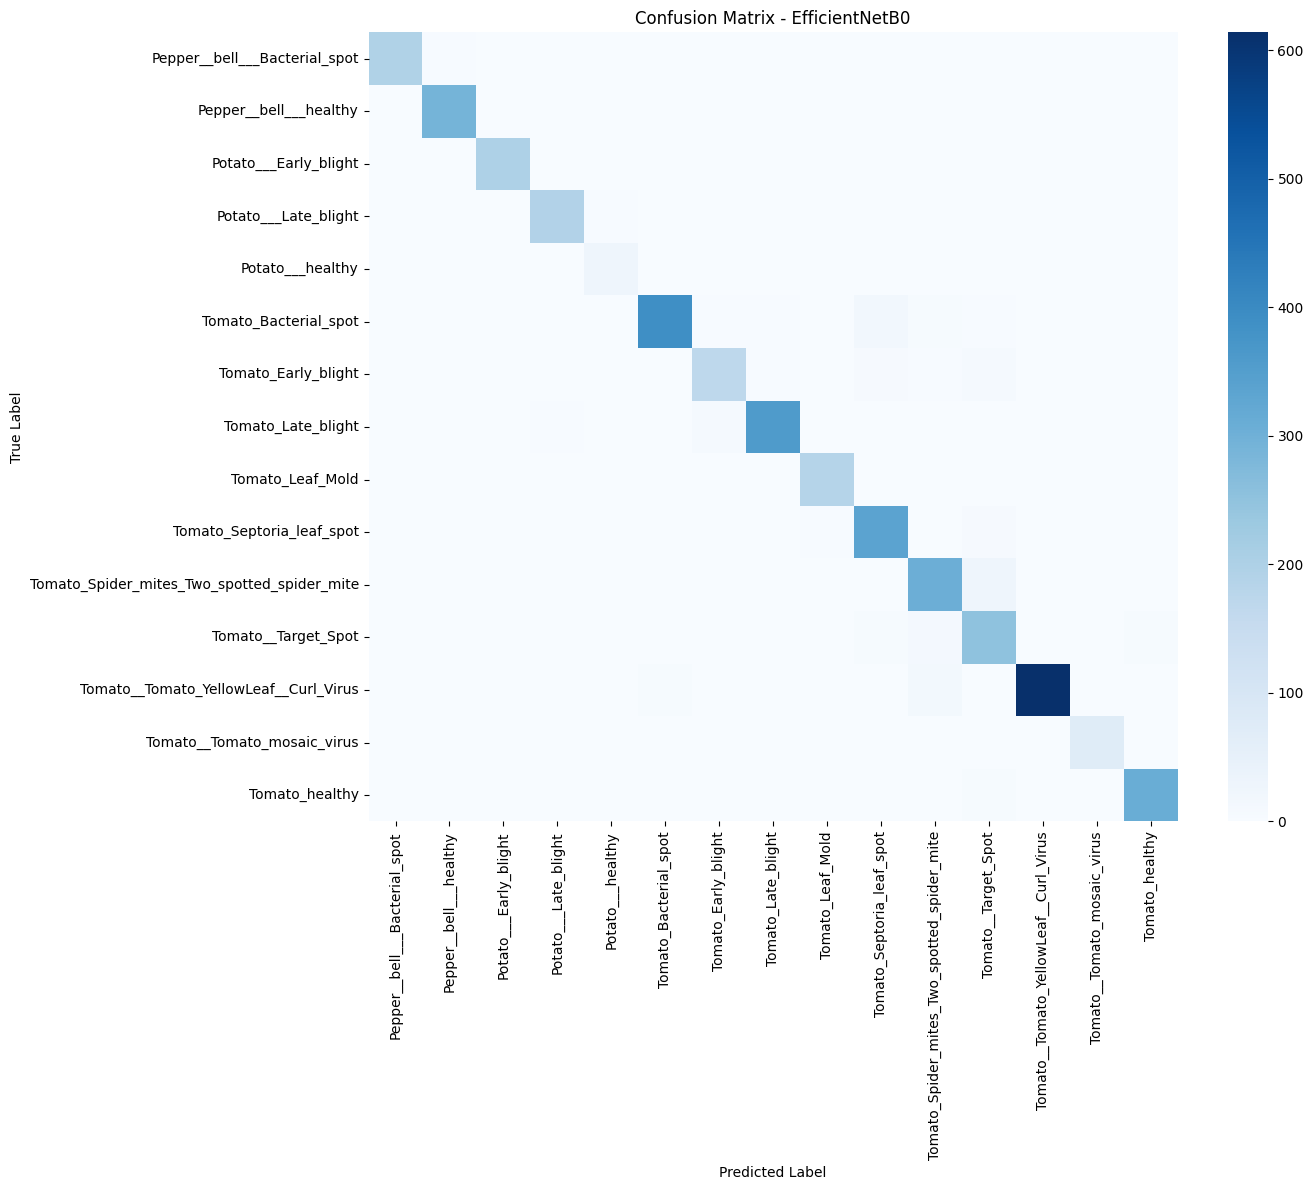

In [ ]:
eff_val_gen.reset()

y_true_eff = eff_val_gen.classes
y_pred_eff = np.argmax(
    effnet_model.predict(eff_val_gen, verbose=1),
    axis=1
)

result_eff = evaluate_model(
    "EfficientNetB0",
    y_true_eff,
    y_pred_eff
)

# results_list.append(result_eff)

# EVALUASI MODEL 3: HYBRID EFFICIENTNETB0-XGBOOST


Model           : Hybrid EfficientNetB0-XGBoost
Accuracy        : 0.9515
Macro Precision : 0.9490
Macro Recall    : 0.9455
Macro F1-Score  : 0.9470
Weighted F1     : 0.9514

Classification Report:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.97      0.97      0.97       199
                     Pepper__bell___healthy       0.98      0.98      0.98       295
                      Potato___Early_blight       0.97      0.97      0.97       200
                       Potato___Late_blight       0.98      0.95      0.97       200
                           Potato___healthy       0.96      0.90      0.93        30
                      Tomato_Bacterial_spot       0.95      0.97      0.96       425
                        Tomato_Early_blight       0.85      0.81      0.83       200
                         Tomato_Late_blight       0.94      0.94      0.94       381
                           Tomato_Le

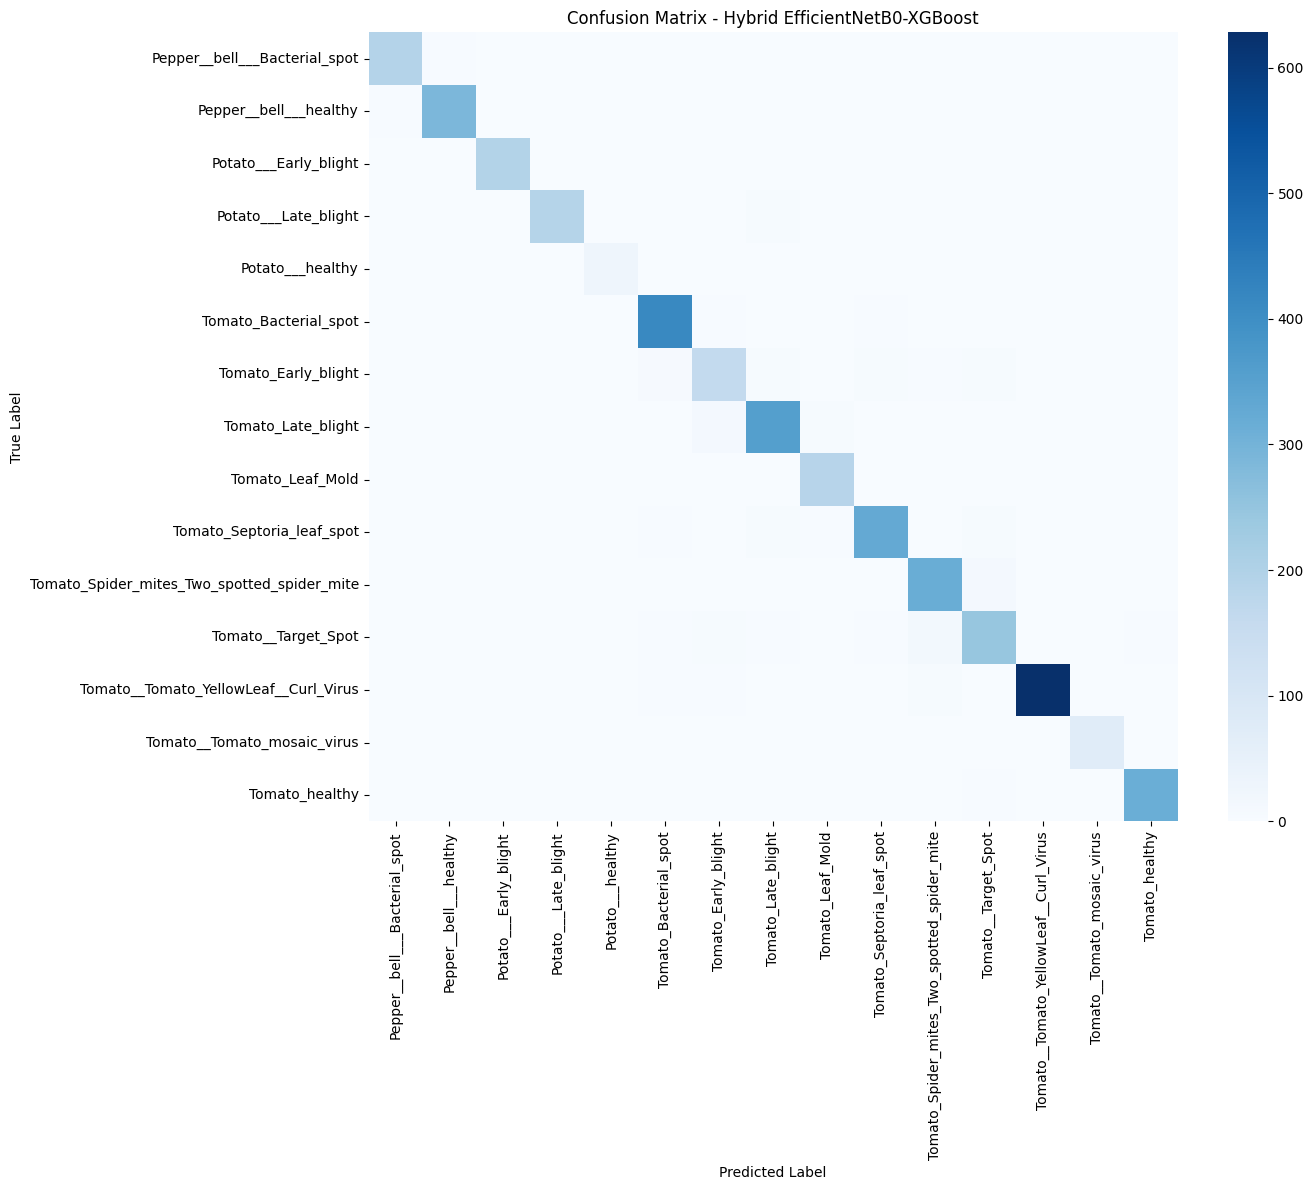

In [ ]:
y_pred_hyb = xgb_model.predict(X_val_feat)

result_hyb = evaluate_model(
    "Hybrid EfficientNetB0-XGBoost",
    y_val_feat,
    y_pred_hyb
)

# results_list.append(result_hyb)

# TABEL PERBANDINGAN HASIL MODEL

In [ ]:
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(
    'Macro F1-Score',
    ascending=False
)

print("Perbandingan Hasil Model:")
print(results_df.to_string(index=False))

NameError: name 'results_list' is not defined

# VISUALISASI PERBANDINGAN MODEL

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(results_df['Model'], results_df['Accuracy'])
plt.ylim(0, 1.05)
plt.title('Perbandingan Accuracy Tiga Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(results_df['Model'], results_df['Macro Recall'])
plt.ylim(0, 1.05)
plt.title('Perbandingan Macro Recall Tiga Model')
plt.ylabel('Macro Recall')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(results_df['Model'], results_df['Macro F1-Score'])
plt.ylim(0, 1.05)
plt.title('Perbandingan Macro F1-Score Tiga Model')
plt.ylabel('Macro F1-Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(results_df['Model'], results_df['Weighted F1-Score'])
plt.ylim(0, 1.05)
plt.title('Perbandingan Weighted F1-Score Tiga Model')
plt.ylabel('Weighted F1-Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()